Loading data...
Preparing features...

Fire counts by temperature bin:
            temp_bin  count           sum
0  (-35.683, -27.32]      2  4.447000e+02
1   (-27.32, -19.04]      0  0.000000e+00
2   (-19.04, -10.76]      2  2.780000e+01
3    (-10.76, -2.48]     22  4.350000e+01
4       (-2.48, 5.8]    221  1.545543e+03
5       (5.8, 14.08]    777  3.459974e+04
6     (14.08, 22.36]   2007  5.134508e+06
7     (22.36, 30.64]   3870  6.402142e+07
8     (30.64, 38.92]   2191  2.089428e+07
9      (38.92, 47.2]     23  1.502295e+04


/var/folders/ns/_jj0q0mn38d5fpjdl9_8ywv00000gn/T/ipykernel_76848/876845936.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_fire_counts = data_state.groupby('temp_bin')['fire_size'].agg(['count', 'sum']).reset_index()



Mean Squared Error: 0.02991001304343597
R-squared Score: 0.6465742165214741

Top 10 Feature Importance:
               feature  importance
6             temp_exp    0.180752
7   temp_elev_interact    0.179217
10             cos_day    0.070176
53            state_TX    0.060638
4           temp_range    0.060014
2                t_min    0.052670
19            state_FL    0.039865
9              sin_day    0.038541
8            elevation    0.037605
1        discovery_doy    0.035512

Predicted Risk Score for 2025-06-15 in CA (T_min: 19, T_max: 40): 0.7519


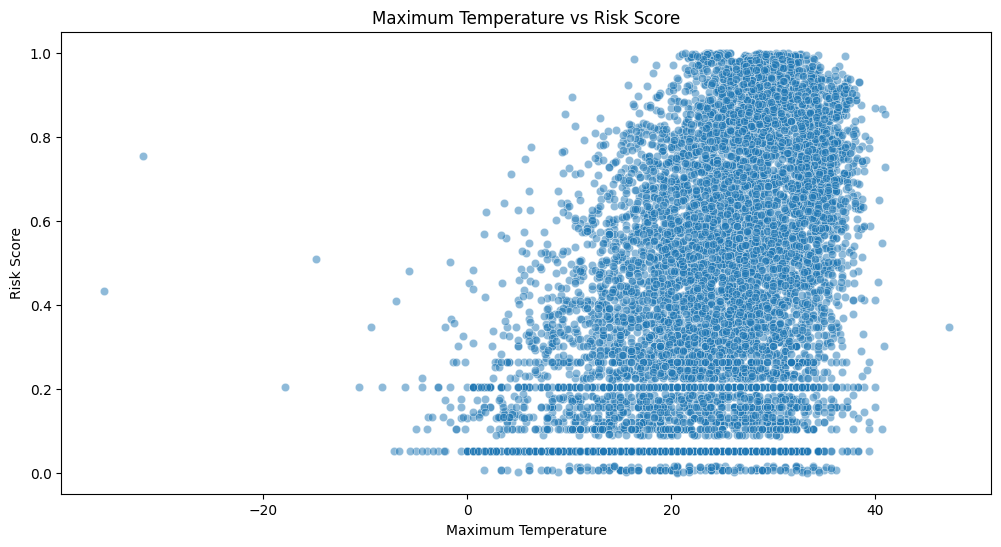

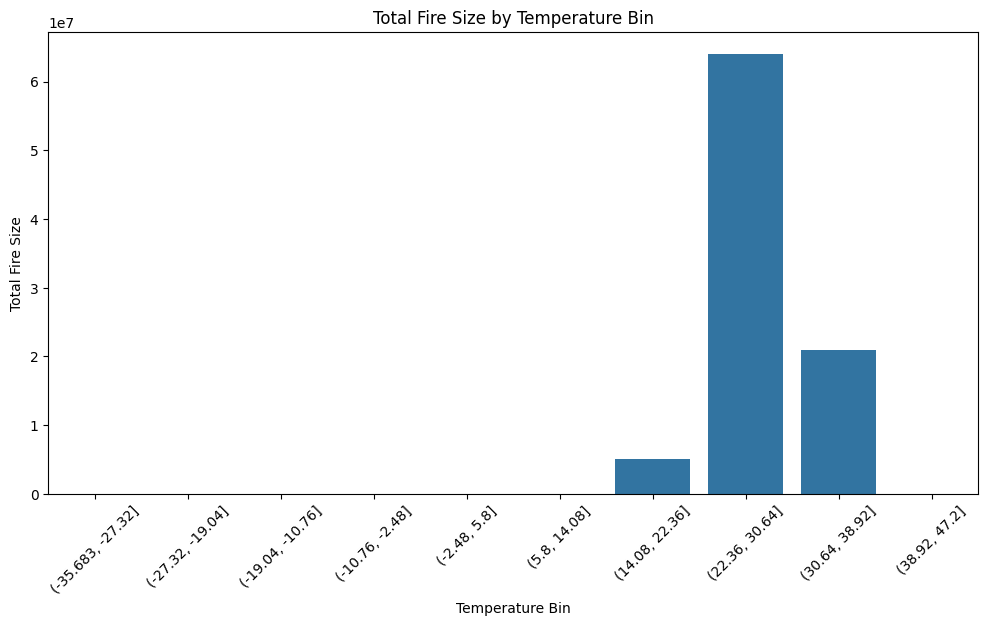

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import QuantileTransformer, RobustScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import mean_squared_error, r2_score
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
print("Loading data...")
# DOWNLOAD THIS FILE: https://syd1.digitaloceanspaces.com/duckgoesmeow/final_merged_data/merged_data.csv
data = pd.read_csv('~/Desktop/merged_data.csv', usecols=['state', 'discovery_month', 'discovery_doy', 't_min', 't_max', 'elevation', 'fire_size'])

# Feature engineering
print("Preparing features...")
data['sin_day'] = np.sin(2 * np.pi * data['discovery_doy']/365)
data['cos_day'] = np.cos(2 * np.pi * data['discovery_doy']/365)
data['temp_range'] = data['t_max'] - data['t_min']
data['temp_squared'] = data['t_max'] ** 2
data['temp_exp'] = np.exp((data['t_max'] - data['t_max'].mean()) / data['t_max'].std())
data['temp_elev_interact'] = data['t_max'] * data['elevation']

# Aggregate data
data_state = data.groupby(['state', 'discovery_month', 'discovery_doy']).agg({
    'fire_size': 'sum',
    't_min': 'mean',
    't_max': 'mean',
    'temp_range': 'mean',
    'temp_squared': 'mean',
    'temp_exp': 'mean',
    'temp_elev_interact': 'mean',
    'elevation': 'mean',
    'sin_day': 'first',
    'cos_day': 'first'
}).reset_index()

# Create temperature bins and count fires
data_state['temp_bin'] = pd.cut(data_state['t_max'], bins=10)
temp_fire_counts = data_state.groupby('temp_bin')['fire_size'].agg(['count', 'sum']).reset_index()
print("\nFire counts by temperature bin:")
print(temp_fire_counts)

# Normalize fire_size to a 0-1 scale for risk_score using QuantileTransformer
qt = QuantileTransformer(output_distribution='uniform', n_quantiles=1000)
data_state['risk_score'] = qt.fit_transform(data_state[['fire_size']])

# Define features and target
features = ['state', 'discovery_month', 'discovery_doy', 't_min', 't_max', 'temp_range', 'temp_squared', 
            'temp_exp', 'temp_elev_interact', 'elevation', 'sin_day', 'cos_day']
target = 'risk_score'

# Prepare the feature matrix X and target vector y
X = pd.get_dummies(data_state[features], columns=['state'])
y = data_state[target]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create sample weights based on temperature and fire size
temp_transformer = QuantileTransformer(output_distribution='normal')
temp_normalized = temp_transformer.fit_transform(X_train[['t_max']])
fire_size_normalized = QuantileTransformer().fit_transform(data_state[data_state.index.isin(X_train.index)][['fire_size']])
sample_weights = np.exp(temp_normalized).flatten() * np.exp(fire_size_normalized).flatten()

# Train RandomForest model
model = RandomForestRegressor(n_estimators=500, max_depth=20, min_samples_split=5, random_state=42, n_jobs=-1)
model.fit(X_train_scaled, y_train, sample_weight=sample_weights)

# Make predictions
y_pred = model.predict(X_test_scaled)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"\nMean Squared Error: {mse}")
print(f"R-squared Score: {r2}")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
})
print("\nTop 10 Feature Importance:")
print(feature_importance.sort_values('importance', ascending=False).head(10))

def predict_risk(date, state, t_min, t_max):
    # Convert date to month and day of year
    date = pd.to_datetime(date)
    month = date.month
    day_of_year = date.timetuple().tm_yday
    
    # Create a DataFrame with all features, initialized to 0
    input_data = pd.DataFrame(0, index=[0], columns=X.columns)
    
    # Fill in the known values
    input_data['discovery_month'] = month
    input_data['discovery_doy'] = day_of_year
    input_data['t_min'] = t_min
    input_data['t_max'] = np.clip(t_max, data['t_max'].min(), data['t_max'].max())  # Clip to range of training data
    input_data['elevation'] = data_state[data_state['state'] == state]['elevation'].mean()
    input_data['sin_day'] = np.sin(2 * np.pi * day_of_year/365)
    input_data['cos_day'] = np.cos(2 * np.pi * day_of_year/365)
    input_data['temp_range'] = input_data['t_max'] - input_data['t_min']
    input_data['temp_squared'] = input_data['t_max'] ** 2
    input_data['temp_exp'] = np.exp((input_data['t_max'] - data['t_max'].mean()) / data['t_max'].std())
    input_data['temp_elev_interact'] = input_data['t_max'] * input_data['elevation']
    
    # Set the correct state column to 1
    state_column = f'state_{state}'
    if state_column in input_data.columns:
        input_data[state_column] = 1
    else:
        print(f"Warning: State '{state}' not found in training data.")
    
    # Scale input data
    input_scaled = scaler.transform(input_data)
    
    # Make prediction
    risk_score = model.predict(input_scaled)[0]
    return risk_score

# Example usage
date = '2025-06-15'
state = 'CA'
t_min = 19
t_max = 40
risk_score = predict_risk(date, state, t_min, t_max)
print(f"\nPredicted Risk Score for {date} in {state} (T_min: {t_min}, T_max: {t_max}): {risk_score:.4f}")

# Visualizations
plt.figure(figsize=(12, 6))
sns.scatterplot(x='t_max', y='risk_score', data=data_state, alpha=0.5)
plt.title('Maximum Temperature vs Risk Score')
plt.xlabel('Maximum Temperature')
plt.ylabel('Risk Score')
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x='temp_bin', y='sum', data=temp_fire_counts)
plt.title('Total Fire Size by Temperature Bin')
plt.xlabel('Temperature Bin')
plt.ylabel('Total Fire Size')
plt.xticks(rotation=45)
plt.show()